# 2606-Data Ecosystems and Governance in Organizations

# 1. Setup

## 1.1. Import Libraries

In [12]:
### Data manipulation
import pandas as pd
import numpy as np

### Visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Statistical testing
import scipy.stats as stats

### Fairness metrics
from fairlearn.metrics import demographic_parity_difference

### Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 1.2. Load Clean Datasets
- We will use Jan 1, 2024 as our baseline date based on our data's processing timestamps

In [13]:
app_df = pd.read_csv('data/processed/applications_clean.csv')
spend_df = pd.read_csv('data/processed/spending_behavior.csv')

## 1.3. Feature Engineering

### 1.3.1. Calculate Age

In [14]:
app_df['applicant_info_date_of_birth'] = pd.to_datetime(app_df['applicant_info_date_of_birth'])
baseline_date = pd.to_datetime('2024-01-01')
app_df['age'] = (baseline_date - app_df['applicant_info_date_of_birth']).dt.days // 365

### 1.3.2. Aggregate Spending
- We need to pivot the spending data so each category becomes its own column

In [15]:
spend_pivot = spend_df.pivot_table(
    index='app_id', 
    columns='category', 
    values='amount', 
    fill_value=0
).reset_index()

## 1.4. Dataframe Adjustments

### 1.4.1. Create master DF
- Merge everything into one master analytical dataframe

In [16]:
merged_df = pd.merge(app_df, spend_pivot, on='app_id', how='left')

### 1.4.2. Handlibng missing values
- Fill NaNs with 0 for any applicants who didn't have specific spending records

In [17]:
spending_categories = spend_pivot.columns.drop('app_id')
merged_df[spending_categories] = merged_df[spending_categories].fillna(0)

In [18]:
merged_df.head()

,app_id,processing_timestamp,applicant_info_full_name,applicant_info_email,applicant_info_ssn,applicant_info_ip_address,applicant_info_gender,applicant_info_date_of_birth,applicant_info_zip_code,financials_annual_income,...,Fitness,Gambling,Groceries,Healthcare,Insurance,Rent,Shopping,Transportation,Travel,Utilities
0,app_200,2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,...,0.0,0.0,0.0,0.0,0.0,790.0,480.0,0.0,0.0,0.0
1,app_037,NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,...,0.0,0.0,0.0,243.0,0.0,608.0,0.0,0.0,0.0,0.0
2,app_215,NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,...,0.0,0.0,0.0,0.0,0.0,109.0,0.0,0.0,0.0,0.0
3,app_024,NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077.0,103000.0,...,575.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,app_184,2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080.0,57000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1.5. Initial Correlation Analysis
- We convert our categorical variables to numeric ones for this step
- We use a Seaborn Heatmap for visualization

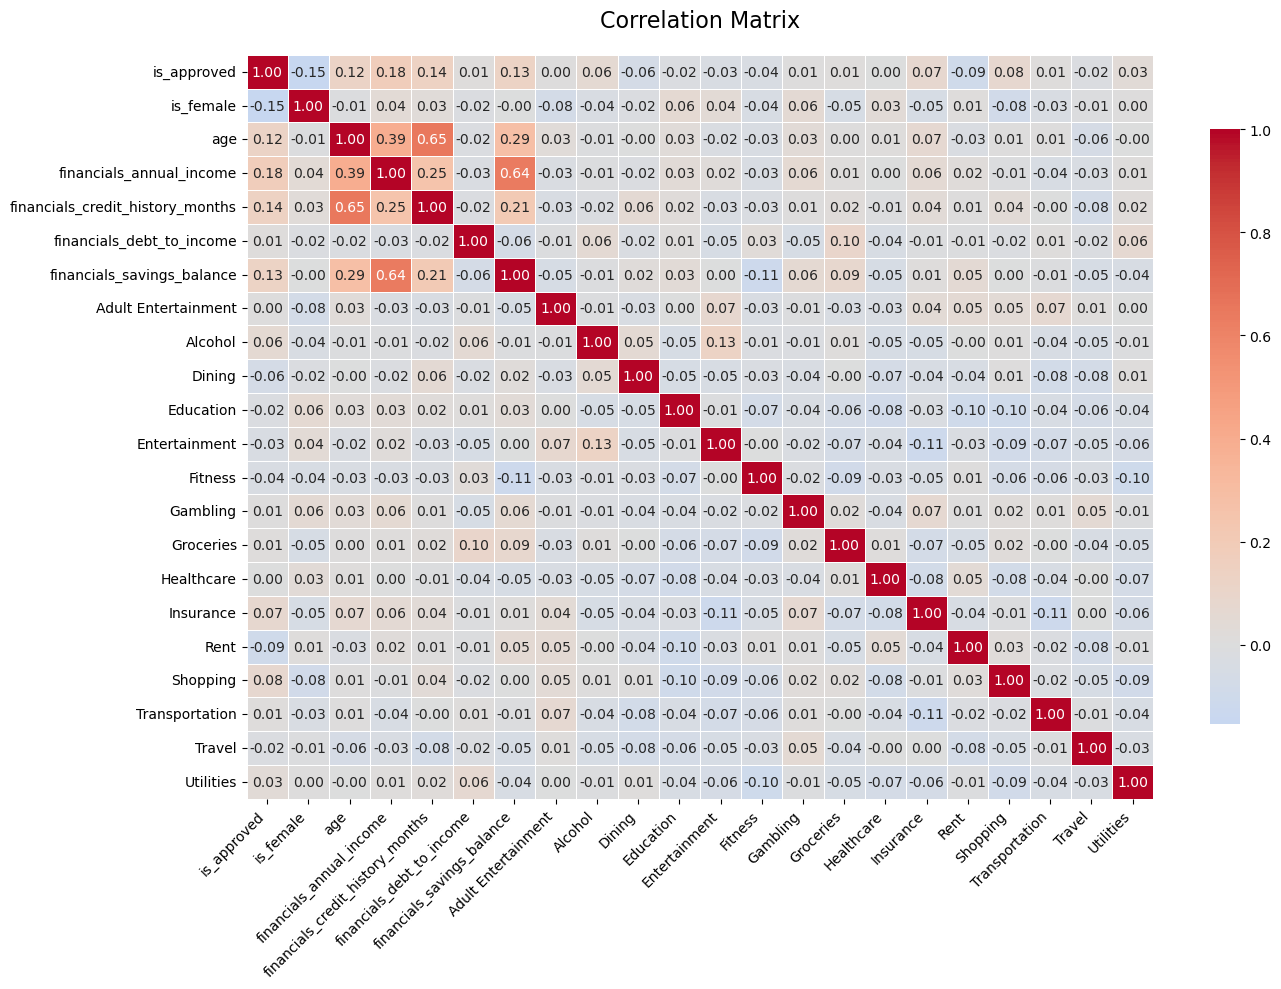

In [35]:
corr_df = merged_df.copy()

# Encode Gender (1 for Female, 0 for Male)
corr_df['is_female'] = (corr_df['applicant_info_gender'] == 'Female').astype(int)

# Encode Loan Approval (1 for True, 0 for False)
corr_df['is_approved'] = corr_df['decision_loan_approved'].astype(int)

# Select the key columns we care about for bias hunting
cols_to_correlate = [
    'is_approved', 'is_female', 'age', 
    'financials_annual_income', 'financials_credit_history_months',
    'financials_debt_to_income', 'financials_savings_balance'
] + list(spending_categories)

correlation_matrix = corr_df[cols_to_correlate].corr()

# Visualizing
plt.figure(figsize=(14, 10))

# Negative correlations are blue and positive are red
sns.heatmap(
    correlation_matrix, 
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Bias Analysis

## 2.1. Gender Bias Analysis

In this section, the gender bias in the dataset will be thoroughly examined, using the Disparate Impact (DI) Ratio and Approval Rate per age group as follows:

$$P(\text{Approved} \mid \text{Age} \in g) = \frac{\sum I(\text{Approved} \cap \text{Age} \in g)}{\sum I(\text{Age} \in g)}$$

$$DI_{\text{Gender}} = \frac{P(\text{Approved} \mid \text{Gender} = \text{Female})}{P(\text{Approved} \mid \text{Gender} = \text{Male})}$$

### 2.1.1. Approval Rates by Gender
- 'decision_loan_approved' is a boolean (True/False).
- Taking the mean() of a boolean column gives us the exact percentage of True values (the approval rate).

In [19]:
gender_approval = merged_df.groupby('applicant_info_gender')['decision_loan_approved'].mean().reset_index()
gender_approval.rename(columns={'decision_loan_approved': 'approval_rate'}, inplace=True)

print("Approval Rates by Gender:")
print(gender_approval.to_string(index=False))
print("\n")

Approval Rates by Gender:
applicant_info_gender  approval_rate
               Female       0.508000
                 Male       0.659919
              Unknown       0.666667




### 2.1.2. Calculate Disparate Impact (DI) Ratio
- We will test Female as the potentially unprivileged group against Male as the privileged group
- The four-fifths rule states a DI < 0.8 indicates potential disparate impact

In [20]:
rate_male = gender_approval[gender_approval['applicant_info_gender'] == 'Male']['approval_rate'].values[0]
rate_female = gender_approval[gender_approval['applicant_info_gender'] == 'Female']['approval_rate'].values[0]

di_ratio_gender = rate_female / rate_male

print(f"Disparate Impact Analysis:")
print(f"Disparate Impact (DI) Ratio (Female/Male): {di_ratio_gender:.4f}")

if di_ratio_gender < 0.8:
    print("DI Ratio is below 0.8. This violates the four-fifths rule and indicates potential gender bias!")
else:
    print("DI Ratio is 0.8 or above. No strict disparate impact flagged by the four-fifths rule.")

Disparate Impact Analysis:
Disparate Impact (DI) Ratio (Female/Male): 0.7698
DI Ratio is below 0.8. This violates the four-fifths rule and indicates potential gender bias!


### 2.1.3. Visualizing the Results

#### 2.1.3.1. Loan Approval Rates by Gender
- Horizontal dashed line for the 80% threshold

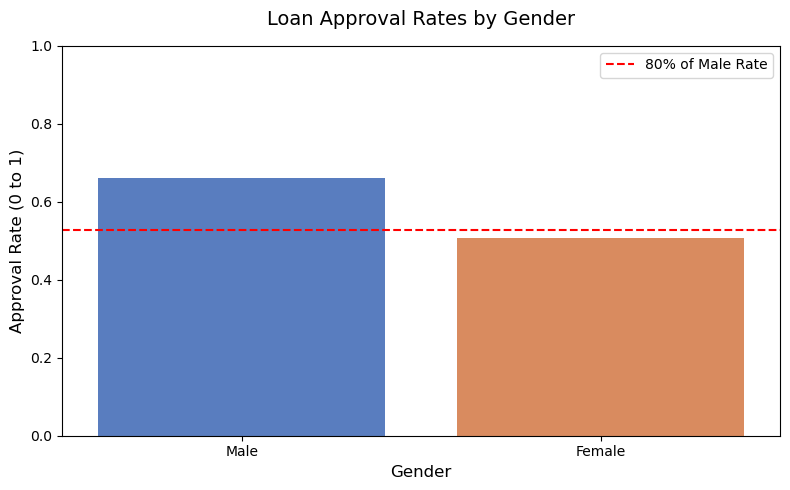

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x='applicant_info_gender', 
    y='approval_rate', 
    data=gender_approval, 
    palette='muted',
    order=['Male', 'Female'],
    ax=ax
)

ax.set_title('Loan Approval Rates by Gender', fontsize=14, pad=15)
ax.set_ylabel('Approval Rate (0 to 1)', fontsize=12)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylim(0, 1) 

### Add horizontal threshold line 
ax.axhline(y=rate_male * 0.8, color='red', linestyle='--', label='80% of Male Rate')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 2.2. Age-Based Discrimination Analysis

In this section, to investigate age-based bias, we segment the continuous age variable into discrete generational groups ($g$) and compare the probability of approval across these. The math is as follows:

$$P(\text{Approved} \mid \text{Age} \in g) = \frac{\sum I(\text{Approved} \cap \text{Age} \in g)}{\sum I(\text{Age} \in g)}$$

$$DI_{\text{Age}} = \frac{P(\text{Approved} \mid \text{Age} \in [18, 25))}{P(\text{Approved} \mid \text{Age} \in [36, 50))}$$

### 2.2.1 Approval Rates by Age Bins 
- We categorize the continuous age variable into logical bins

In [29]:
bins = [18, 26, 36, 51, 100]
labels = ['18-25', '26-35', '36-50', '50+']
merged_df['age_group'] = pd.cut(merged_df['age'], bins=bins, labels=labels, right=False)

age_approval = merged_df.groupby('age_group')['decision_loan_approved'].mean().reset_index()
age_approval.rename(columns={'decision_loan_approved': 'approval_rate'}, inplace=True)

print("Approval Rates by Age Group:")
print(age_approval.to_string(index=False))
print("\n")

Approval Rates by Age Group:
age_group  approval_rate
    18-25       0.361702
    26-35       0.527950
    36-50       0.673913
      50+       0.576923




### 2.2.2. Calculate Disparate Impact (DI) Ratio
- We determine the DI Ratio for Age (Youngest vs. Prime Earning Years)
- We test the 18-25 group (potentially unprivileged) against the 36-50 group (potentially privileged)

In [28]:
rate_young = age_approval[age_approval['age_group'] == '18-25']['approval_rate'].values[0]
rate_middle = age_approval[age_approval['age_group'] == '36-50']['approval_rate'].values[0]

if rate_middle > 0:
    di_ratio_age = rate_young / rate_middle
    print(f"Age Disparate Impact (18-25 vs 36-50):")
    print(f"DI Ratio: {di_ratio_age:.4f}")
    if di_ratio_age < 0.8:
        print("Potential age-based bias detected against younger applicants (< 0.8)")
    else:
        print("No strict DI flagged for this specific age comparison.")
else:
    print("Cannot calculate DI: Privileged group approval rate is 0.")

Age Disparate Impact (18-25 vs 36-50):
DI Ratio: 0.5367
Potential age-based bias detected against younger applicants (< 0.8)


### 2.2.3. Visualizing the Results
- Horizontal dashed line for the '36-50' group's 80% threshold

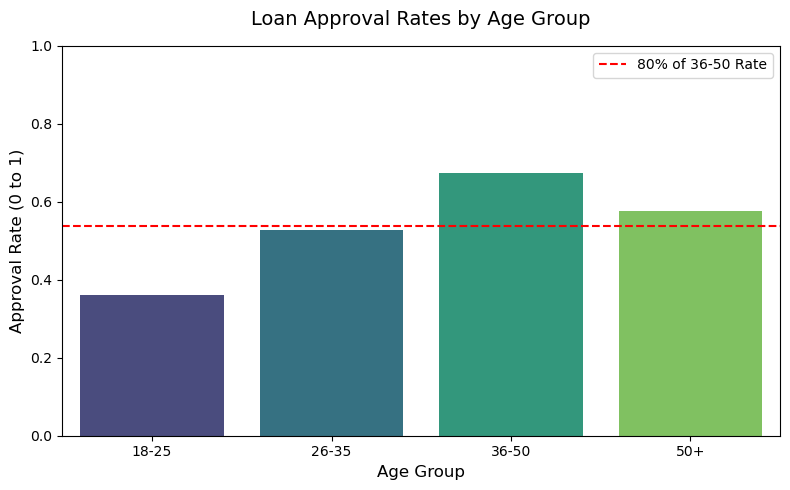

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x='age_group', 
    y='approval_rate', 
    data=age_approval, 
    palette='viridis',
    ax=ax
)

ax.set_title('Loan Approval Rates by Age Group', fontsize=14, pad=15)
ax.set_ylabel('Approval Rate (0 to 1)', fontsize=12)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylim(0, 1)

# Add horizontal threshold line
if rate_middle > 0:
    ax.axhline(y=rate_middle * 0.8, color='red', linestyle='--', label='80% of 36-50 Rate')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 2.3. Proxy Discrimination Analysis

A non-protected attribute $X_{proxy}$ (e.g., ZIP code, spending category) acts as a proxy for a protected attribute $A$ (e.g., Gender) if it is highly correlated with $A$ and significantly impacts the decision outcome $Y$.

**Point-Biserial Correlation (Spending vs. Approval):**
To measure the relationship between a continuous spending category and the binary loan approval outcome, we use the point-biserial correlation coefficient:
$$r_{pb} = \frac{M_1 - M_0}{s_n} \sqrt{\frac{n_1 n_0}{n^2}}$$
*(Where $M_1$ and $M_0$ are the mean spending of the approved and rejected groups respectively).*

### 2.3.1. Geographic Proxy Analysis (ZIP Codes)
- We aggregate the data by ZIP code
- We have a filter for ZIP codes with at least 5 applicants to reduce statistical noise

In [47]:
# Aggregation
zip_analysis = merged_df.groupby('applicant_info_zip_code').agg(
    applicant_count=('app_id', 'count'),
    approval_rate=('decision_loan_approved', 'mean'),
    female_ratio=('applicant_info_gender', lambda x: (x == 'Female').mean())
).reset_index()

# Filter for ZIP codes
zip_analysis = zip_analysis[zip_analysis['applicant_count'] >= 5]

# Calculate Pearson correlation
zip_corr, zip_pval = stats.pearsonr(zip_analysis['female_ratio'], zip_analysis['approval_rate'])
print(f"Correlation between Female Ratio and ZIP Approval Rate: {zip_corr:.3f} (p-value: {zip_pval:.3f})")

if zip_corr < -0.3 and zip_pval < 0.05:
    print("Strong negative correlation found! ZIP code might be acting as a proxy for Gender.")
else:
    print("No strong, statistically significant proxy effect found for ZIP codes overall.")
print("\n")

Correlation between Female Ratio and ZIP Approval Rate: -0.222 (p-value: 0.361)
No strong, statistically significant proxy effect found for ZIP codes overall.




### 2.3.2. Behavioral Proxy Analysis (Spending Categories)

In [48]:
proxy_results = []

for category in spending_categories:
    spend_by_gender = merged_df.groupby('applicant_info_gender')[category].mean()
    male_spend = spend_by_gender.get('Male', 0)
    female_spend = spend_by_gender.get('Female', 0)
    
    # Correlation between spending in this category and getting approved
    corr, p_val = stats.pointbiserialr(merged_df[category], merged_df['decision_loan_approved'])
    
    proxy_results.append({
        'Category': category,
        'Male_Avg_Spend': male_spend,
        'Female_Avg_Spend': female_spend,
        'Approval_Correlation': corr
    })

proxy_df = pd.DataFrame(proxy_results)
proxy_df['Gender_Difference'] = proxy_df['Female_Avg_Spend'] - proxy_df['Male_Avg_Spend']

# Sort by the most negatively correlated with approval (categories that get people rejected)
proxy_df = proxy_df.sort_values('Approval_Correlation', ascending=True)

print("Spending Categories impacting Loan Approval (Negative = Higher Rejection):")
print()
print(proxy_df[['Category', 'Approval_Correlation', 'Male_Avg_Spend', 'Female_Avg_Spend']].head(5).to_string(index=False))




Spending Categories impacting Loan Approval (Negative = Higher Rejection):

     Category  Approval_Correlation  Male_Avg_Spend  Female_Avg_Spend
         Rent             -0.094076       60.809717            63.480
       Dining             -0.062201       66.182186            57.556
      Fitness             -0.036439       69.546559            56.008
Entertainment             -0.031319       60.441296            79.608
       Travel             -0.020914       81.307692            77.556


### 2.3.3. Visualizing the Results
- Plot 1: ZIP Code Proxy
- Plot 2: Top Proxy Spending Category (The most negative correlation)

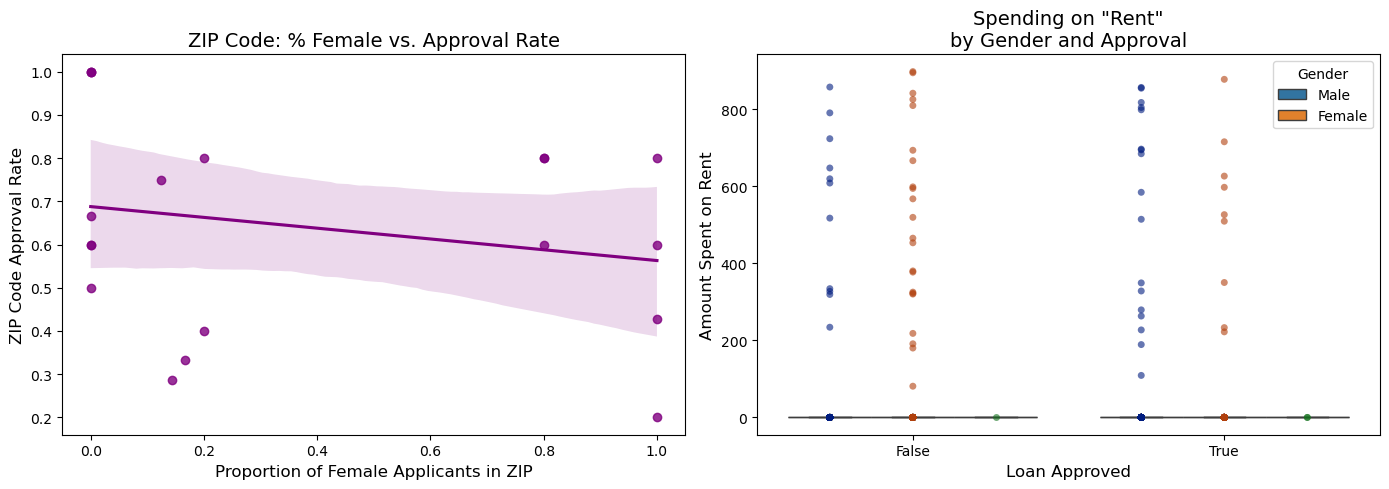

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1
sns.regplot(
    x='female_ratio', 
    y='approval_rate', 
    data=zip_analysis, 
    ax=axes[0],
    color='purple'
)
axes[0].set_title('ZIP Code: % Female vs. Approval Rate', fontsize=14)
axes[0].set_xlabel('Proportion of Female Applicants in ZIP', fontsize=12)
axes[0].set_ylabel('ZIP Code Approval Rate', fontsize=12)

# Plot 2
top_proxy_category = proxy_df.iloc[0]['Category']
sns.boxplot(
    x='decision_loan_approved', 
    y=top_proxy_category, 
    hue='applicant_info_gender', 
    data=merged_df,
    ax=axes[1],
    showfliers=False
)

sns.stripplot(
    x='decision_loan_approved', 
    y=top_proxy_category, 
    hue='applicant_info_gender', 
    data=merged_df,
    ax=axes[1],
    palette='dark',
    dodge=True,
    alpha=0.6,
    jitter=False
)

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[:2], labels[:2], title='Gender', loc='upper right')

axes[1].set_title(f'Spending on "{top_proxy_category}"\nby Gender and Approval', fontsize=14)
axes[1].set_xlabel('Loan Approved', fontsize=12)
axes[1].set_ylabel(f'Amount Spent on {top_proxy_category}', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Exploratory Data Analysis

## 3.1 Univariate Analysis

(Target Variable Check, Numerical values and distribution, Categorial values)

## 3.2 Correlation Analysis

## 3.3 Bivariate Analysis

(Correlation between two Variables)


## 3.4 Multivariate Analysis 